In [2]:
import torch

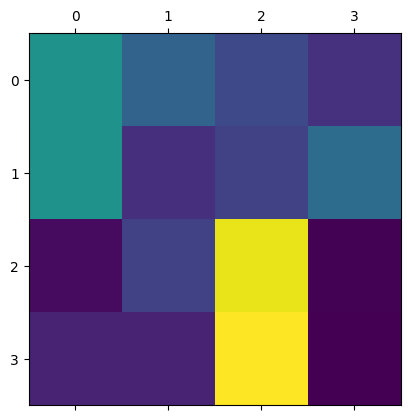

In [251]:
from matplotlib import pyplot as plt
import numpy as np

def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


n = 4
W = generate_W(n)

plt.matshow(W)

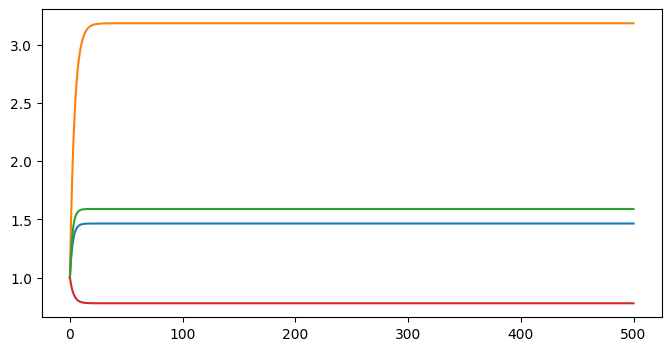

In [10]:
def step(P: np.ndarray, W: np.ndarray):

    new_P = np.zeros_like(P)
    W = np.copy(W)
    np.fill_diagonal(W, 0)

    outgoing = np.sum(W, axis=1)
    incoming = np.sum(W, axis=0)

    for i_classifier, (Pi, inc, out) in enumerate(zip(P, incoming, outgoing, strict=True)):
        new_P[i_classifier] = out * (Pi + inc)

    return new_P


def solve(P0: np.ndarray, W: np.ndarray, steps: int):

    Ps = [P0]
    P = P0
    for _ in range(steps):
        P = step(P, W)
        Ps.append(P)

    return np.array(Ps)


P0 = np.ones(n)
Ps = solve(P0, W, 500)

fig, ax  = plt.subplots(figsize=(8, 4))

for i_classifier in range(Ps.shape[1]):
    ax.plot(Ps[:, i_classifier])

In [84]:
def generate_W(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    return W / w_sum


def generate_W_w(n: int):
    # Sample intrinsic self-vote weights for each voter
    alphas = np.random.rand(n)  # α_i in [0,1] for each voter i

    # Initialize a matrix for delegation probabilities.
    # For each voter j, we will generate a probability distribution over all i ≠ j.
    p = np.zeros((n, n))
    for j in range(n):
        # Get indices for "other" voters (excluding self)
        others = [i for i in range(n) if i != j]
        # Generate random positive numbers for these indices
        rand_vals = np.random.rand(len(others))
        # Normalize so that they sum to 1
        p[j, others] = rand_vals / rand_vals.sum()

    # Now, each voter j delegates a fraction (1 - α_j) of their vote according to p[j, :].
    # In our fixed point equation, we want:
    #   x_i = α_i + Σ_j (1-α_j)*p[j, i] * x_j.
    # So define a matrix M where M[j, i] = (1-α_j)*p[j, i].
    M = (1 - alphas)[:, np.newaxis] * p  # shape (n, n)

    # For the fixed point equation in the form x = w + W x, we want W[i, j]
    # to represent the delegation contribution from voter j to voter i.
    # That is, we set:
    #    W[i, j] = (1-α_j)*p[j, i]   <=>   W = M^T.
    W = M.T

    # Return W and the intrinsic weights vector (w = alphas)
    return W, alphas

n = 4
W, w = generate_W_w(n)

def solve_fixed_point(W: np.ndarray, w: np.ndarray):

    W = np.copy(W.T)
    np.fill_diagonal(W, 0)
    stable = np.linalg.pinv(np.identity(W.shape[0]) - W) @ w[:, np.newaxis]

    return np.squeeze(stable)

solve_fixed_point(W, w)

array([1., 1., 1., 1.])

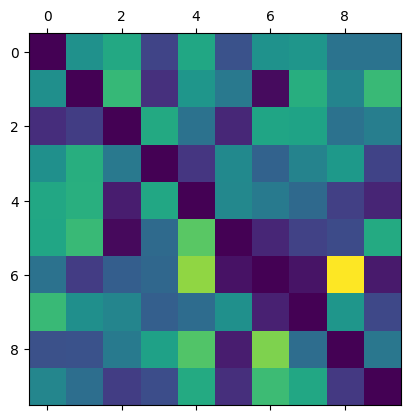

In [222]:
def generate_W_p(n: int):

    W = np.random.random((n, n))
    w_sum = np.sum(W, axis=1, keepdims=True)
    W =  W / w_sum

    p = np.diag(np.copy(W))
    np.fill_diagonal(W, 0)

    return W, p

W, p = generate_W_p(10)
plt.matshow(W)

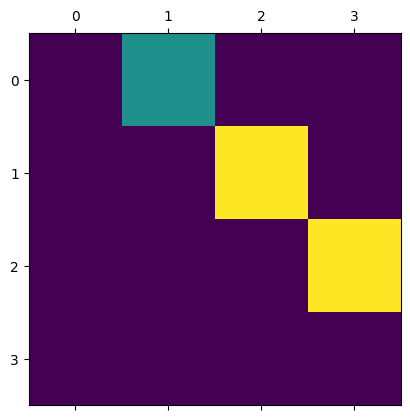

In [416]:
W = np.array([
    [0, 0.5, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 1],
], dtype=float)

p = np.ones(W.shape[0])
np.fill_diagonal(W, 0.0)

plt.matshow(W)

In [418]:
import numpy as np


def step(p: np.ndarray, W: np.ndarray):
    out = np.sum(W, axis=1)
    incoming = np.dot(W.T, p)
    new_p = (1 - out) * p + incoming
    return new_p

def solve_iterative(W: np.ndarray, p: np.ndarray, iterations: int = 100):
    for _ in range(iterations):
        p = step(p, W)
    return p

print(solve_iterative(W, p))


[7.88860905e-31 7.88860905e-31 1.57772181e-30 4.00000000e+00]


Final delegatable = [1.  1.5 1.  0. ]
Final kept        = [0.  0.  0.  0.5]

Final             = [1.  1.5 1.  0.5]
Total power       = 4.0


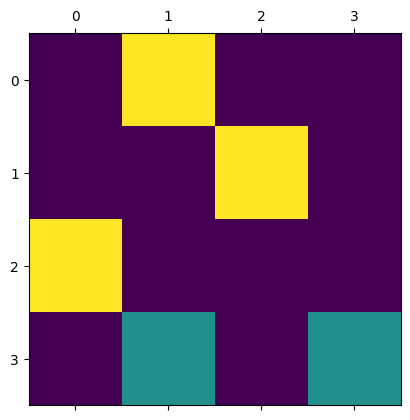

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def step_keep_portion_locked(p_delegatable, p_kept, W):
    """
    One synchronous iteration where:
      - diagonal W[i,i] = fraction that i 'locks away' from its current delegatable power
      - off-diagonal W[i,j] add up to (1 - W[i,i]), telling how to split the remainder
      - anything locked this round is added to p_kept (and removed from delegatable power)

    Returns (new_delegatable, new_kept).
    """
    n = len(p_delegatable)

    # We'll accumulate new "incoming" delegatable power in a fresh array:
    new_delegatable = np.zeros_like(p_delegatable)
    new_kept = p_kept.copy()

    # Precompute how much each row sums off-diagonal (should be 1 - diag if row sums to 1)
    # but we won't assume it must be exactly 1 - diag(...) in case you have partial rows
    row_sums_offdiag = np.sum(W, axis=1) - np.diag(W)

    # First, figure out how much each voter keeps (this round) and how much outflows
    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount

    # Lock the 'keep' portion into p_kept
    new_kept += keep_amount

    # Distribute the outflow to other voters proportionally:
    for i in range(n):
        denom = row_sums_offdiag[i]
        if denom > 0:
            # If there's some fraction going out, distribute among j != i
            for j in range(n):
                if j != i and W[i,j] > 0:
                    frac = W[i,j] / denom
                    incoming_j = frac * outflow[i]
                    new_delegatable[j] += incoming_j
        else:
            # If row_sums_offdiag[i] == 0, then i doesn't delegate to others
            # (maybe i is a 'full sink' => W[i,i] = 1 or the row is all 0)
            # so i effectively keeps all leftover
            new_kept[i] += outflow[i]

    return new_delegatable, new_kept

def solve_iterative_locked(W, p_init, max_iter=1000, tol=1e-12):
    """
    Iteratively apply step_keep_portion_locked until stable or max_iter.

    p_init: initial delegatable power for each voter.
            (If each voter starts with 1, then sum is the total "4".)
    """
    p_delegatable = p_init.astype(float).copy()
    p_kept = np.zeros_like(p_delegatable)

    for _ in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()

        new_delegatable, new_kept = step_keep_portion_locked(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()

        # Check that total power is conserved (up to float epsilon)
        if not np.isclose(old_sum, new_sum, atol=1e-9):
            print(f"Warning: total power changed from {old_sum} to {new_sum}")

        # Check for convergence
        if (np.allclose(new_delegatable, p_delegatable, atol=tol) and
            np.allclose(new_kept, p_kept, atol=tol)):
            return new_delegatable, new_kept

        p_delegatable, p_kept = new_delegatable, new_kept

    return p_delegatable, p_kept


W = np.array([
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 0.5, 0.0, 0.5],
])

plt.matshow(W)

p_init = np.array([1,1,1,1], dtype=float)  # 4 voters each start with 1 delegatable
p_delegatable_final, p_kept_final = solve_iterative_locked(W, p_init)

print("Final delegatable =", p_delegatable_final)
print("Final kept        =", p_kept_final)
print("\nFinal             =", p_kept_final  + p_delegatable_final)
print("Total power       =", p_delegatable_final.sum() + p_kept_final.sum())


In [9]:
%matplotlib qt

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

def step_keep_portion_locked(p_delegatable, p_kept, W):
    n = len(p_delegatable)
    new_delegatable = np.zeros_like(p_delegatable)
    new_kept = p_kept.copy()
    row_sums_offdiag = np.sum(W, axis=1) - np.diag(W)
    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount
    new_kept += keep_amount
    for i in range(n):
        denom = row_sums_offdiag[i]
        if denom > 0:
            for j in range(n):
                if j != i and W[i,j] > 0:
                    frac = W[i,j] / denom
                    new_delegatable[j] += frac * outflow[i]
        else:
            new_kept[i] += outflow[i]
    return new_delegatable, new_kept

def solve_iterative_locked(W, p_init, max_iter=1000, tol=1e-12):
    p_delegatable = p_init.astype(float).copy()
    p_kept = np.zeros_like(p_delegatable)
    for _ in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()
        new_delegatable, new_kept = step_keep_portion_locked(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()
        if not np.isclose(old_sum, new_sum, atol=1e-9):
            print(f"Warning: total power changed from {old_sum} to {new_sum}")
        if (np.allclose(new_delegatable, p_delegatable, atol=tol) and
            np.allclose(new_kept, p_kept, atol=tol)):
            return new_delegatable, new_kept
        p_delegatable, p_kept = new_delegatable, new_kept
    return p_delegatable, p_kept

class InteractiveW:
    def __init__(self, n=4):
        self.n = n
        self.W = np.zeros((n, n))
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        plt.subplots_adjust(bottom=0.2)
        self.im = self.ax.imshow(self.W, cmap="gray", vmin=0, vmax=1)
        self.ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        self.ax.tick_params(which="both", bottom=False, left=False, labelbottom=True, labelleft=True)
        self.fig.canvas.mpl_connect("button_press_event", self.onclick)
        button_ax = self.fig.add_axes([0.8, 0.05, 0.15, 0.075])
        self.button = Button(button_ax, "Calculate")
        self.button.on_clicked(self.calculate)
        self.res_ax = self.fig.add_axes([0.1, 0.05, 0.65, 0.075])
        self.res_ax.axis("off")
        self.result_text = self.res_ax.text(0.5, 0.5, "",
                                              horizontalalignment="center",
                                              verticalalignment="center",
                                              transform=self.res_ax.transAxes,
                                              fontsize=12)

    def onclick(self, event):
        # Ensure the click occurred in our matrix axes and that xdata/ydata are defined.
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return

        # Use rounding to identify the closest cell center
        col = int(np.rint(event.xdata))
        row = int(np.rint(event.ydata))
        if 0 <= row < self.n and 0 <= col < self.n:
            current = self.W[row, col]

            if event.button == 1:
                add = 0.5
            else:
                add = 0.25

            current += add
            if current > 1.0:
                current = 0

            self.W[row, col] = current
            self.im.set_data(self.W)
            self.fig.canvas.draw_idle()

    def calculate(self, event):
        p_init = np.ones(self.n)
        p_delegate, p_kept = solve_iterative_locked(self.W, p_init)
        p_final = p_kept + p_delegate
        result_str = f"{p_final.sum():.2f} " + np.array2string(p_final, precision=3)
        self.result_text.set_text(result_str)
        self.fig.canvas.draw_idle()

demo = InteractiveW(n=4)
plt.show()


In [351]:
def solve_fixed_point(W: np.ndarray, p: np.ndarray):

    alpha = 0.9

    W = alpha * np.copy(W.T)
    np.fill_diagonal(W, 0)
    inv = np.linalg.pinv(np.identity(W.shape[0]) - W)
    stable = inv @ (p[:, np.newaxis])

    return np.squeeze(stable)

solve_fixed_point(W, p + np.ones(W.shape[0]))

array([10., 10.,  2.,  2.])

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button

def step_keep_portion_locked(p_delegatable, p_kept, W):
    n = len(p_delegatable)
    new_delegatable = np.zeros_like(p_delegatable)
    new_kept = p_kept.copy()
    row_sums_offdiag = np.sum(W, axis=1) - np.diag(W)
    keep_amount = np.diag(W) * p_delegatable
    outflow = p_delegatable - keep_amount
    new_kept += keep_amount
    for i in range(n):
        denom = row_sums_offdiag[i]
        if denom > 0:
            for j in range(n):
                if j != i and W[i,j] > 0:
                    frac = W[i,j] / denom
                    new_delegatable[j] += frac * outflow[i]
        else:
            new_kept[i] += outflow[i]
    return new_delegatable, new_kept

def solve_iterative_locked(W, p_init, max_iter=1000, tol=1e-12):
    p_delegatable = p_init.astype(float).copy()
    p_kept = np.zeros_like(p_delegatable)
    for _ in range(max_iter):
        old_sum = p_delegatable.sum() + p_kept.sum()
        new_delegatable, new_kept = step_keep_portion_locked(p_delegatable, p_kept, W)
        new_sum = new_delegatable.sum() + new_kept.sum()
        if not np.isclose(old_sum, new_sum, atol=1e-9):
            print(f"Warning: total power changed from {old_sum} to {new_sum}")
        if (np.allclose(new_delegatable, p_delegatable, atol=tol) and
            np.allclose(new_kept, p_kept, atol=tol)):
            return new_delegatable, new_kept
        p_delegatable, p_kept = new_delegatable, new_kept
    return p_delegatable, p_kept

class InteractiveW:
    def __init__(self, n=4):
        self.n = n
        self.W = np.zeros((n, n))
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        plt.subplots_adjust(bottom=0.2)
        self.im = self.ax.imshow(self.W, cmap="gray", vmin=0, vmax=1)
        self.ax.set_title("Click on cells to cycle values (0 → 0.5 → 1.0)")
        self.ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        self.ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        self.ax.tick_params(which="both", bottom=False, left=False, labelbottom=True, labelleft=True)
        self.fig.canvas.mpl_connect("button_press_event", self.onclick)
        button_ax = self.fig.add_axes([0.8, 0.05, 0.15, 0.075])
        self.button = Button(button_ax, "Calculate")
        self.button.on_clicked(self.calculate)
        self.res_ax = self.fig.add_axes([0.1, 0.05, 0.65, 0.075])
        self.res_ax.axis("off")
        self.result_text = self.res_ax.text(0.5, 0.5, "",
                                              horizontalalignment="center",
                                              verticalalignment="center",
                                              transform=self.res_ax.transAxes,
                                              fontsize=12)

    def onclick(self, event):
        # Ensure the click occurred in our matrix axes and that xdata/ydata are defined.
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return


        # Use rounding to identify the closest cell center
        col = int(np.rint(event.xdata))
        row = int(np.rint(event.ydata))
        if 0 <= row < self.n and 0 <= col < self.n:
            current = self.W[row, col]
            # Cycle through 0, 0.5, 1.0

            if event.button == 1:
                add = 0.5
            else:
                add = 0.25

            current += add

            if current > 1.0:
                current = 0

            self.W[row, col] = current
            self.im.set_data(self.W)
            self.fig.canvas.draw_idle()

    def calculate(self, event):
        p_init = np.ones(self.n)
        _, p_kept_final = solve_iterative_locked(self.W, p_init)
        result_str = "Final kept power: " + np.array2string(p_kept_final, precision=3)
        self.result_text.set_text(result_str)
        self.fig.canvas.draw_idle()

demo = InteractiveW(n=4)
plt.show()


In [187]:
import torch

bs = 15
n = 4

Ds = [torch.rand((bs, n), requires_grad=True) for _ in range(n)]
Ds_cat_ready = [torch.unsqueeze(d, -1) for d in Ds]
D = torch.cat(Ds_cat_ready, dim=-1)

p = torch.diagonal(D, dim1=-2, dim2=-1)
mask = torch.ones_like(D)
mask = torch.ones_like(D)
batch_indices = torch.arange(bs).unsqueeze(1).unsqueeze(2)
diag_indices = torch.arange(n).unsqueeze(0).expand(n, -1)
mask[batch_indices, diag_indices, diag_indices] = 0
D_no_diag = D * mask

identity = torch.zeros_like(D)
identity[batch_indices, diag_indices, diag_indices] = 1

p_column = p.unsqueeze(-1)
inverse = torch.pinverse(identity - D_no_diag)
influence = torch.bmm(inverse, p_column)
influence = torch.squeeze(influence)

influence.sum().backward()
Ds[0].grad

tensor([[-2.1357e+00,  3.6265e+00,  1.1176e+00,  3.6910e+00],
        [-8.3647e+00,  6.5824e+00,  2.1243e+00,  6.4119e+00],
        [-1.1760e+00,  8.4928e-01,  1.8983e-01,  7.9119e-01],
        [-2.1929e+00,  8.7414e-01,  7.1433e-01,  1.5521e+00],
        [-2.1542e+00,  2.7343e+00,  2.7598e+00,  3.0652e+00],
        [-1.3913e+00,  1.0445e+00,  1.4449e+00,  7.3552e-01],
        [-2.4541e+01,  3.2504e+02,  3.9021e+02,  6.3721e+02],
        [-1.4137e+00,  1.6525e+00,  1.4320e+00,  5.8267e-01],
        [-5.3871e+00,  2.0789e+01,  1.7634e+01,  1.3988e+01],
        [-1.8161e+01,  1.0851e+02,  5.6026e+01,  7.1462e+01],
        [-1.2609e+00,  1.7677e+00,  6.3777e-01,  1.3811e+00],
        [-2.5434e+00,  4.7205e+00,  5.7598e+00,  7.4937e+00],
        [-8.0925e+01,  5.8892e+02,  6.2427e+02,  8.4758e+02],
        [-5.5893e+00,  1.3715e+01,  7.0365e+00,  6.3492e+00],
        [-3.8388e+00,  3.6738e+00,  6.0307e+00,  4.9316e+00]])